# WNGF Worked Example: Cross & Parker (2004) R&D Manufacturing Network

This notebook is an example use case showing how to apply the general-purpose WNGF code
(see `WNGF_reusable_implementation.ipynb` in this repo) to a real, publicly available dataset — one
of the two case studies used in:

> Zádor, Zhu, Smith & Gorgoni (2022), *A Weighted and Normalized Gould–Fernandez brokerage measure*, PLOS ONE. https://doi.org/10.1371/journal.pone.0274475

**Data**: an intra-organizational advice-seeking network from a research & development team at
a manufacturing company (77 employees), originally collected by Cross & Parker (2004) and
hosted publicly by Tore Opsahl:
https://toreopsahl.com/datasets/#Cross_Parker

- Tie weight (0–6): how frequently person *i* turns to person *j* for work-related advice.
- Node attribute: each employee's office location — Paris, Frankfurt, Warsaw, or Geneva.

## Setup

In [1]:
import math
from collections import Counter

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

%matplotlib inline


## WNGF core functions

In [2]:
def build_wngf_network(weights, groups, directed=True, self_loops=False):
    """Build a networkx graph ready for WNGF, from either a square weight matrix or an edge list."""
    is_matrix = isinstance(weights, pd.DataFrame) and set(weights.index) == set(weights.columns)

    if is_matrix:
        nodes = list(weights.index)
        G = nx.DiGraph() if directed else nx.Graph()
        G.add_nodes_from(nodes)
        for i in nodes:
            for j in nodes:
                if i == j and not self_loops:
                    continue
                w = weights.loc[i, j]
                w = 0.0 if pd.isna(w) else float(w)
                G.add_edge(i, j, weight=w)
    else:
        edge_df = weights
        group_nodes = list(groups.keys()) if isinstance(groups, dict) else list(groups.index)
        nodes = sorted(set(edge_df['source']) | set(edge_df['target']) | set(group_nodes))
        G = nx.DiGraph() if directed else nx.Graph()
        G.add_nodes_from(nodes)
        for i in nodes:
            for j in nodes:
                if i == j and not self_loops:
                    continue
                G.add_edge(i, j, weight=0.0)
        for _, row in edge_df.iterrows():
            if row['source'] == row['target'] and not self_loops:
                continue
            G[row['source']][row['target']]['weight'] = float(row['weight'])

    group_map = dict(groups)
    missing = [n for n in G.nodes if n not in group_map]
    if missing:
        raise ValueError(f"No group label provided for {len(missing)} node(s), e.g. {missing[:10]}.")
    nx.set_node_attributes(G, {n: group_map[n] for n in G.nodes}, name='group')
    return G


def _is_broker(w_qr, w_rs, w_qs):
    if w_qr > 0 and w_rs > 0:
        if w_qs == 0:
            return True
        return (1.0 / w_qs) > (1.0 / w_qr + 1.0 / w_rs)
    return False


def _classify_role(g_q, g_r, g_s):
    if g_q == g_r == g_s:
        return 'coordinator'
    elif g_q == g_s and g_r != g_q:
        return 'itinerant'
    elif g_q != g_s and g_r == g_s:
        return 'gatekeeper'
    elif g_q == g_r and g_r != g_s:
        return 'representative'
    elif g_q != g_r and g_r != g_s and g_q != g_s:
        return 'liaison'
    return None


def _nCr(n, r):
    if r < 0 or r > n or n < 0:
        return 0
    return math.comb(n, r)


def _normalization_denominators(own_group, group_counts):
    n = group_counts[own_group]
    others = {g: c for g, c in group_counts.items() if g != own_group}

    co = _nCr(n - 1, 2) * 2 if n > 2 else 1
    ga_re = sum(c * (n - 1) for c in others.values()) if n > 1 else 1
    it = sum(_nCr(c, 2) * 2 for c in others.values() if c > 1)

    li = 0
    items = list(others.items())
    for g1, c1 in items:
        for g2, c2 in items:
            if g1 != g2:
                li += c1 * c2

    return {'coordinator': co or 1, 'gatekeeper': ga_re or 1,
            'representative': ga_re or 1, 'itinerant': it or 1, 'liaison': li or 1}


def compute_wngf(G, group_attr='group', normalize=True, return_pairs=False):
    group_map = nx.get_node_attributes(G, group_attr)
    group_counts = Counter(group_map.values())

    role_names = ['coordinator', 'itinerant', 'gatekeeper', 'representative', 'liaison']
    rows = []
    pairs_by_node = {}

    for node in G.nodes:
        own_group = group_map[node]
        counts = {r: 0 for r in role_names}
        pairs = {r: [] for r in role_names}

        for q in G.predecessors(node):
            for s in G.successors(node):
                if q == s:
                    continue
                w_qr = G[q][node]['weight']
                w_rs = G[node][s]['weight']
                w_qs = G[q][s]['weight'] if G.has_edge(q, s) else 0.0

                if _is_broker(w_qr, w_rs, w_qs):
                    role = _classify_role(group_map[q], own_group, group_map[s])
                    if role:
                        counts[role] += 1
                        pairs[role].append((q, s))

        row = {'node': node, 'group': own_group}
        for r in role_names:
            row[f'{r}_raw'] = counts[r]
        row['total_raw'] = sum(counts.values())

        if normalize:
            denom = _normalization_denominators(own_group, group_counts)
            for r in role_names:
                row[f'{r}_norm'] = counts[r] / denom[r]
            row['total_norm'] = sum(row[f'{r}_norm'] for r in role_names)

        rows.append(row)
        pairs_by_node[node] = pairs

    df = pd.DataFrame(rows).set_index('node')
    if return_pairs:
        return df, pairs_by_node
    return df


## Load the data

Data is available from Tore Opsahl's public dataset page. For ease of use, you can load it from the data folder.

https://toreopsahl.com/datasets/#Cross_Parker


In [ ]:
matrix_path = '../data/Cross_Parker-Manufacturing_info (differentiated in terms of advice).xlsx'
attribute_path = '../data/Cross_Parker-Manufacturing_ATTR.xlsx'

# Matrix
matrix = pd.read_excel(matrix_path, header=0, index_col=0)
matrix.index = matrix.index.astype(str)
matrix.columns = matrix.columns.astype(str)

# Attributes
attributes = pd.read_excel(attribute_path, header=0, index_col=0)
attributes.index = attributes.index.astype(str)


In [22]:
# Map location codes to city names
city_names = {1: 'Paris', 2: 'Frankfurt', 3: 'Warsaw', 4: 'Geneva'}
groups = attributes['location'].map(city_names).to_dict()

## Build the network and compute WNGF

In [29]:
G = build_wngf_network(matrix, groups)

results = compute_wngf(G)
results.head()

,group,coordinator_raw,itinerant_raw,gatekeeper_raw,representative_raw,liaison_raw,total_raw,coordinator_norm,itinerant_norm,gatekeeper_norm,representative_norm,liaison_norm,total_norm
node,,,,,,,,,,,,,
1,Paris,5,0,0,0,0,5,0.020833,0.0,0.000000,0.000000,0.000000,0.020833
2,Paris,9,0,0,0,0,9,0.037500,0.0,0.000000,0.000000,0.000000,0.037500
3,Paris,43,0,2,35,0,80,0.179167,0.0,0.002083,0.036458,0.000000,0.217708
4,Paris,14,0,79,66,10,169,0.058333,0.0,0.082292,0.068750,0.004299,0.213674
5,Paris,31,0,38,142,13,224,0.129167,0.0,0.039583,0.147917,0.005589,0.322256


## Explore the results


In [34]:
#as based on the published paper
highlighted_nodes = ['12', '14', '17', '67']

degree = {n: G.in_degree(n) for n in G.nodes} 
real_degree = (matrix.ne(0).sum(axis=1) + matrix.ne(0).sum(axis=0))

comparison = results.loc[highlighted_nodes, ['group', 'total_raw', 'total_norm']].copy()
comparison['advice_ties'] = real_degree.loc[highlighted_nodes].values
comparison['mean_advice_ties'] = real_degree.mean()
comparison

,group,total_raw,total_norm,advice_ties,mean_advice_ties
node,,,,,
12,Paris,233,0.404184,50,57.87013
14,Paris,254,0.246430,55,57.87013
17,Paris,23,0.035847,29,57.87013
67,Geneva,47,0.086458,36,57.87013


In [35]:
# Top overall brokers by normalized total WNGF score
results.sort_values('total_norm', ascending=False).head(10)[
    ['group', 'coordinator_norm', 'itinerant_norm', 'gatekeeper_norm', 'representative_norm', 'liaison_norm', 'total_norm']
]


,group,coordinator_norm,itinerant_norm,gatekeeper_norm,representative_norm,liaison_norm,total_norm
node,,,,,,,
68,Geneva,0.362500,0.028830,0.610417,0.878125,0.545572,2.425444
15,Paris,0.283333,0.003295,0.334375,0.885417,0.291058,1.797478
13,Paris,0.304167,0.009885,0.441667,0.488542,0.216251,1.460511
28,Frankfurt,0.184615,0.001276,0.054615,0.848462,0.061825,1.150793
29,Frankfurt,0.370769,0.005102,0.238462,0.286154,0.067227,0.967714
49,Warsaw,0.123810,0.000000,0.010929,0.763934,0.025269,0.923942
55,Warsaw,0.309524,0.000803,0.257923,0.308197,0.044325,0.920771
74,Geneva,0.058333,0.000000,0.023958,0.738542,0.027085,0.847918
18,Frankfurt,0.110769,0.000000,0.230769,0.382308,0.069628,0.793474


In [36]:
# Top gatekeepers
results.sort_values('gatekeeper_norm', ascending=False).head(10)[['group', 'gatekeeper_norm']]

,group,gatekeeper_norm
node,,
68,Geneva,0.610417
13,Paris,0.441667
15,Paris,0.334375
23,Frankfurt,0.262308
55,Warsaw,0.257923
54,Warsaw,0.248087
29,Frankfurt,0.238462
18,Frankfurt,0.230769
56,Warsaw,0.222951


## Visualize brokerage roles by location

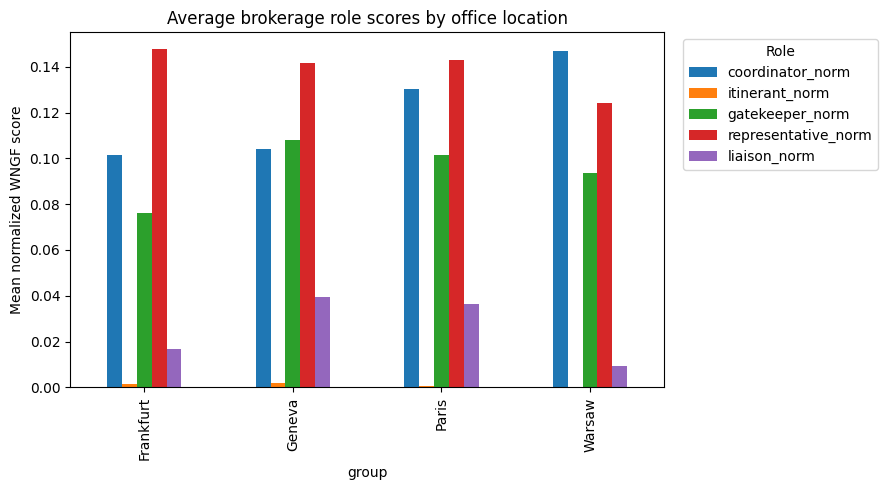

In [37]:
role_cols = ['coordinator_norm', 'itinerant_norm', 'gatekeeper_norm', 'representative_norm', 'liaison_norm']

avg_by_group = results.groupby('group')[role_cols].mean()

fig, ax = plt.subplots(figsize=(9, 5))
avg_by_group.plot(kind='bar', ax=ax)
ax.set_ylabel('Mean normalized WNGF score')
ax.set_title('Average brokerage role scores by office location')
ax.legend(title='Role', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


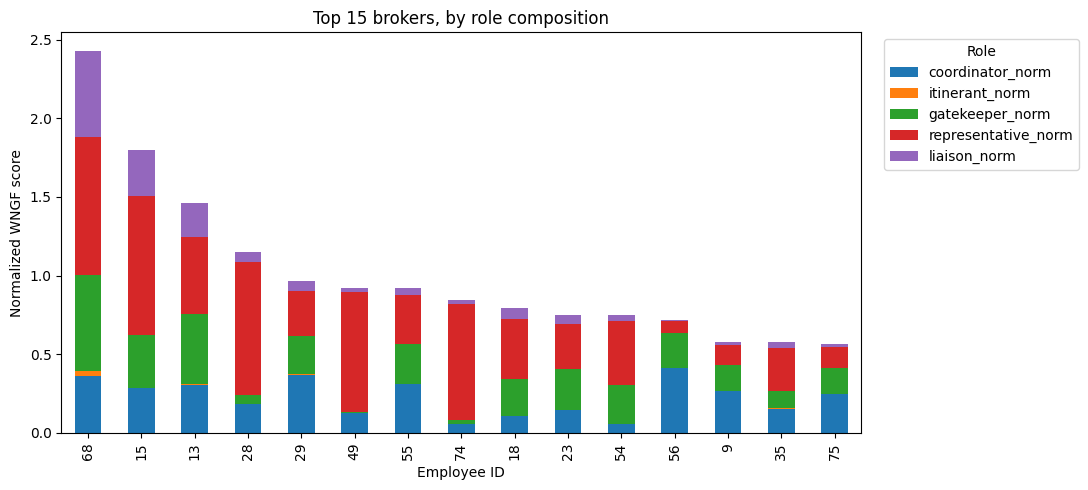

In [39]:
fig, ax = plt.subplots(figsize=(11, 5))
results.sort_values('total_norm', ascending=False).head(15)[role_cols].plot(kind='bar', stacked=True, ax=ax)
ax.set_ylabel('Normalized WNGF score')
ax.set_xlabel('Employee ID')
ax.set_title('Top 15 brokers, by role composition')
ax.legend(title='Role', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Save results


In [ ]:
# results.to_csv('wngf_manufacturing_results.csv')

---
### Reference

Cross, R., Parker, A. (2004). *The Hidden Power of Social Networks*. Harvard Business School Press.

Zádor, Z., Zhu, Z., Smith, M., Gorgoni, S. (2022). A Weighted and Normalized Gould–Fernandez
brokerage measure. *PLOS ONE* 17(9): e0274475. https://doi.org/10.1371/journal.pone.0274475

Dataset: Opsahl, T. — https://toreopsahl.com/datasets/#Cross_Parker
